#Importing Modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Importing pytorch modules

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import random_split

#Importing and Loading Data

In [ ]:
# load data
train_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor())
test_data  = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

# train/val split
train_size = int(0.9 * len(train_data))
val_size   = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

# dataloaders
batch_size = 64
train_dl = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_dl   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False)
test_dl  = DataLoader(test_data,    batch_size=batch_size, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.3MB/s]


#Defining Autoencoder Model

In [ ]:
class Autoencoder(nn.Module):
  def __init__(self, latent_dimension=32): #initially setting bottleneck as 32
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256), nn.ReLU(),
        nn.Linear(256, 64), nn.ReLU(),
        nn.Linear(64, latent_dimension)
    )
    self.decoder = nn.Sequential(
        nn.Linear(latent_dimension, 64), nn.ReLU(),
        nn.Linear(64, 256), nn.ReLU(),
        nn.Linear(256, 784), nn.Sigmoid()
    )
  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded.view(-1, 1, 28, 28)

#Setting Model Parameters

In [ ]:
model = Autoencoder(latent_dimension=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#Training Loop

In [ ]:
losses_train = []
losses_val = []

for epoch in range(20):
    # training
    model.train()
    epoch_loss = 0
    for imgs, _ in train_dl:
        recon = model(imgs)
        loss = criterion(recon, imgs)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    avg_train_loss = epoch_loss / len(train_dl)
    losses_train.append(avg_train_loss)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, _ in val_dl:
            recon = model(imgs)
            loss = criterion(recon, imgs)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_dl)
    losses_val.append(avg_val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1 | Train Loss: 0.0323 | Val Loss: 0.0213
Epoch 2 | Train Loss: 0.0191 | Val Loss: 0.0180
Epoch 3 | Train Loss: 0.0168 | Val Loss: 0.0159
Epoch 4 | Train Loss: 0.0153 | Val Loss: 0.0148
Epoch 5 | Train Loss: 0.0142 | Val Loss: 0.0138
Epoch 6 | Train Loss: 0.0134 | Val Loss: 0.0132
Epoch 7 | Train Loss: 0.0128 | Val Loss: 0.0128
Epoch 8 | Train Loss: 0.0124 | Val Loss: 0.0123
Epoch 9 | Train Loss: 0.0120 | Val Loss: 0.0119
Epoch 10 | Train Loss: 0.0117 | Val Loss: 0.0119
Epoch 11 | Train Loss: 0.0114 | Val Loss: 0.0114
Epoch 12 | Train Loss: 0.0111 | Val Loss: 0.0113
Epoch 13 | Train Loss: 0.0109 | Val Loss: 0.0112
Epoch 14 | Train Loss: 0.0107 | Val Loss: 0.0107
Epoch 15 | Train Loss: 0.0106 | Val Loss: 0.0107
Epoch 16 | Train Loss: 0.0104 | Val Loss: 0.0105
Epoch 17 | Train Loss: 0.0103 | Val Loss: 0.0104
Epoch 18 | Train Loss: 0.0101 | Val Loss: 0.0103
Epoch 19 | Train Loss: 0.0100 | Val Loss: 0.0102
Epoch 20 | Train Loss: 0.0099 | Val Loss: 0.0101


#Plotting Training v/s Validation Loss

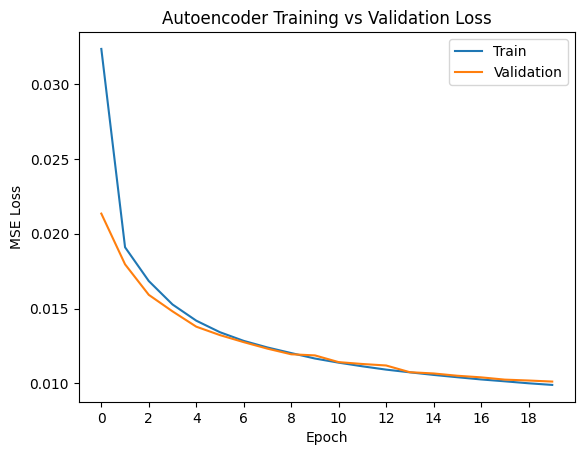

In [ ]:
plt.plot(losses_train, label='Train')
plt.plot(losses_val, label='Validation')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss")
plt.xticks(range(0, 20, 2))
plt.legend()
plt.show()

#Visualizing Original v/s Reconstructed

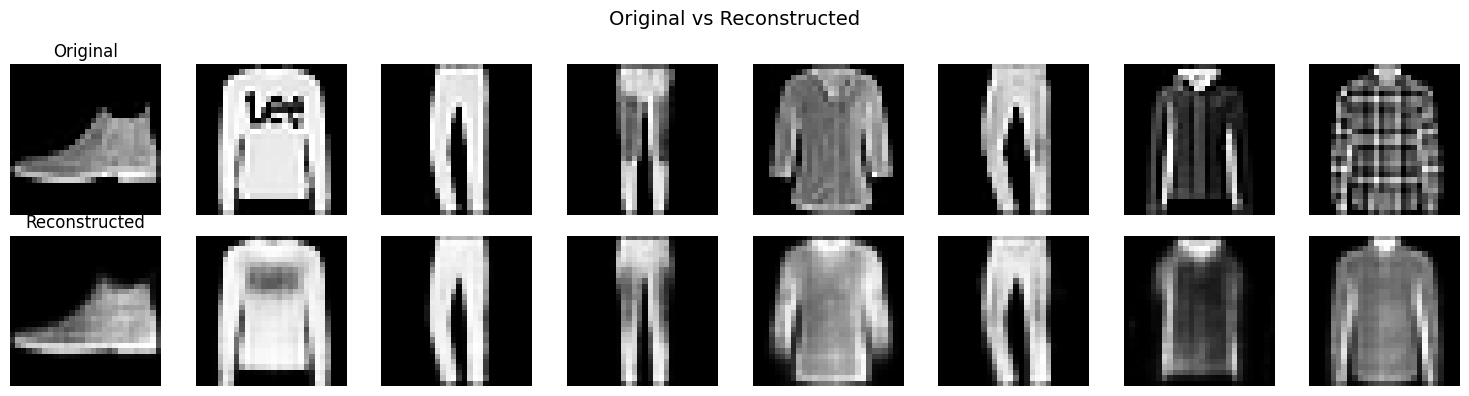

In [ ]:
model.eval()
imgs, _ = next(iter(test_dl))
with torch.no_grad():
    recon = model(imgs[:8])

fig, axs = plt.subplots(2, 8, figsize=(15, 4))
for i in range(8):
    axs[0, i].imshow(imgs[i].squeeze(), cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].imshow(recon[i].squeeze(), cmap='gray')
    axs[1, i].axis('off')
axs[0, 0].set_title('Original', fontsize=12)
axs[1, 0].set_title('Reconstructed', fontsize=12)
plt.suptitle('Original vs Reconstructed', fontsize=14)
plt.tight_layout()
plt.show()

#Experiment - Bottleneck Size

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bottleneck_sizes = [8, 16, 32, 64, 128]
bottleneck_results = {}

for bottleneck in bottleneck_sizes:
    print(f"Training with bottleneck size: {bottleneck}")

    bt_model = Autoencoder(latent_dimension=bottleneck).to(device)
    bt_optimizer = torch.optim.Adam(bt_model.parameters(), lr=1e-3)
    bt_criterion = nn.MSELoss()

    bt_losses_train = []
    bt_losses_val = []

    for epoch in range(20):
        # training
        bt_model.train()
        epoch_loss = 0
        for imgs, _ in train_dl:
            imgs = imgs.to(device)
            recon = bt_model(imgs)
            loss = bt_criterion(recon, imgs)
            bt_optimizer.zero_grad(); loss.backward(); bt_optimizer.step()
            epoch_loss += loss.item()
        bt_losses_train.append(epoch_loss / len(train_dl))

        # validation
        bt_model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, _ in val_dl:
                imgs = imgs.to(device)
                recon = bt_model(imgs)
                val_loss += bt_criterion(recon, imgs).item()
        bt_losses_val.append(val_loss / len(val_dl))

    bottleneck_results[bottleneck] = {
        'train': bt_losses_train,
        'val': bt_losses_val,
        'model': bt_model
    }
    print(f"  Final val loss: {bt_losses_val[-1]:.4f}")

Training with bottleneck size: 8
  Final val loss: 0.0139
Training with bottleneck size: 16
  Final val loss: 0.0112
Training with bottleneck size: 32
  Final val loss: 0.0100
Training with bottleneck size: 64
  Final val loss: 0.0095
Training with bottleneck size: 128
  Final val loss: 0.0094


#Loss vs Bottleneck Size

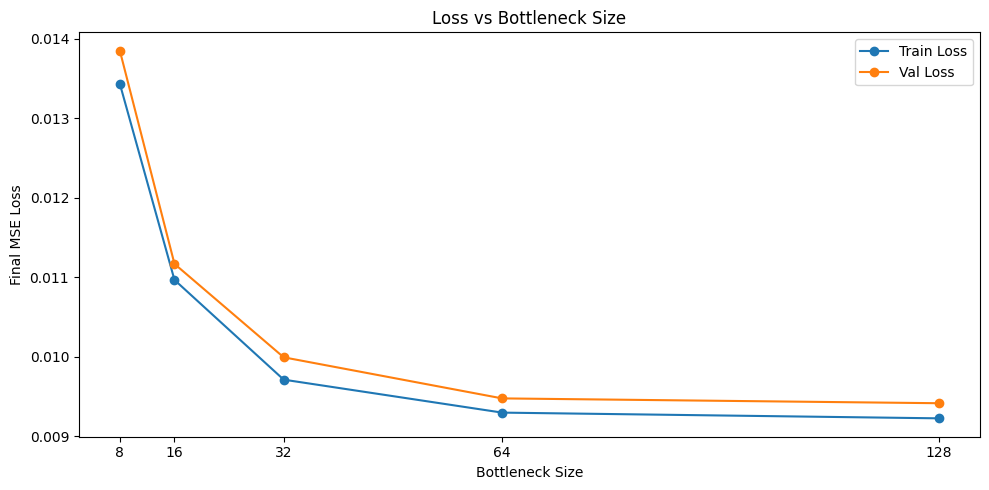

In [ ]:
final_train_losses = [bottleneck_results[b]['train'][-1] for b in bottleneck_sizes]
final_val_losses   = [bottleneck_results[b]['val'][-1]   for b in bottleneck_sizes]

plt.figure(figsize=(10, 5))
plt.plot(bottleneck_sizes, final_train_losses, marker='o', label='Train Loss')
plt.plot(bottleneck_sizes, final_val_losses,   marker='o', label='Val Loss')
plt.xlabel('Bottleneck Size')
plt.ylabel('Final MSE Loss')
plt.title('Loss vs Bottleneck Size')
plt.legend()
plt.xticks(bottleneck_sizes)
plt.tight_layout()
plt.show()

#Visualization for Various Bottleneck Sizes

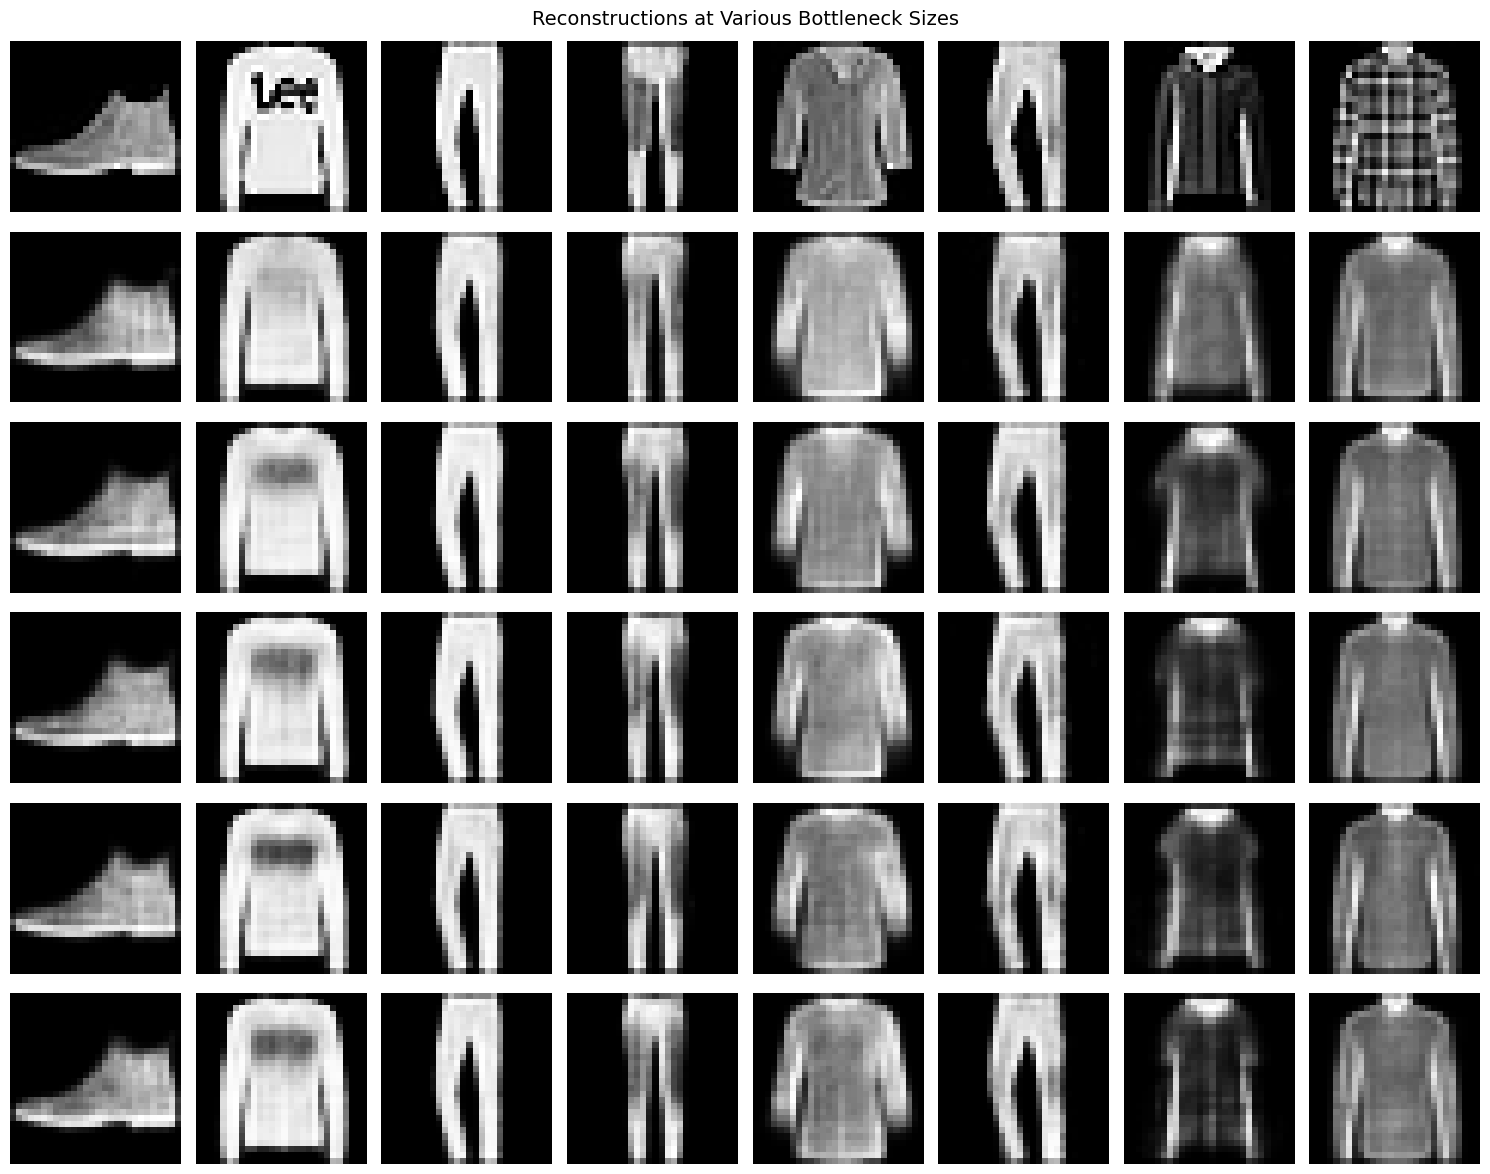

In [ ]:
imgs, _ = next(iter(test_dl))
imgs = imgs.to(device)
sample_imgs = imgs[:8]

n_bottlenecks = len(bottleneck_sizes)
fig, axs = plt.subplots(n_bottlenecks + 1, 8, figsize=(15, 2 * (n_bottlenecks + 1)))

# row 0: originals
for i in range(8):
    axs[0, i].imshow(sample_imgs[i].squeeze().cpu(), cmap='gray')
    axs[0, i].axis('off')
axs[0, 0].set_ylabel('Original', fontsize=10, rotation=90)

# rows 1+: reconstructions per bottleneck
for row, bottleneck in enumerate(bottleneck_sizes):
    bt_model = bottleneck_results[bottleneck]['model']
    bt_model.eval()
    with torch.no_grad():
        recon = bt_model(sample_imgs)
    for i in range(8):
        axs[row + 1, i].imshow(recon[i].squeeze().cpu(), cmap='gray')
        axs[row + 1, i].axis('off')
    axs[row + 1, 0].set_ylabel(f'BN={bottleneck}', fontsize=10, rotation=90)

plt.suptitle('Reconstructions at Various Bottleneck Sizes', fontsize=14)
plt.tight_layout()
plt.show()